# HVAC Electricity Demand analysis and prediction

## Daily Demand Regression Analysis

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)


In [2]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70080 entries, 2010-12-01 00:00:00 to 2018-11-28 23:00:00
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   air_pressure               70080 non-null  float64
 1   air_temperature            70080 non-null  float64
 2   relative_humidity          70080 non-null  float64
 3   wind_speed                 70080 non-null  float64
 4   solar_irridiation          70080 non-null  int64  
 5   total_cloud_cover_percent  70080 non-null  float64
 6   electricity_demand_values  70080 non-null  float64
 7   heat_demand_values         70080 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 4.8 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
air_pressure,70080.0,734.587334,5.006131,716.500000,731.400000,734.200000,737.500000,757.500000
air_temperature,70080.0,17.874431,10.669905,-14.400000,10.000000,18.900000,25.600000,43.300000
relative_humidity,70080.0,60.645077,21.979472,4.000000,43.000000,61.000000,79.000000,100.000000
wind_speed,70080.0,4.830608,2.581267,0.000000,3.000000,5.000000,6.000000,26.000000
solar_irridiation,70080.0,257.293094,258.725788,0.000000,0.000000,299.500000,499.000000,699.000000
total_cloud_cover_percent,70080.0,0.323900,0.387351,0.000000,0.000000,0.000000,0.750000,1.000000
electricity_demand_values,70080.0,393.894392,239.177728,112.947618,227.708651,323.095501,476.911512,1592.893206
heat_demand_values,70080.0,263.551003,314.720551,0.000000,0.000000,137.430266,448.333458,1529.168786


## Create daily dataframe

- Transform the hourly data to daily dataset

In [14]:
df_daily = pd.DataFrame()  # create a new dataframe to store daily data

mean_cols = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "solar_irridiation",
    "total_cloud_cover_percent",
]

for _ in mean_cols:
    df_daily[_] = (
        df[_].resample("D").mean()
    )  # resample daily data with mean from hourly data

In [15]:
df_daily["electricity_demand_values"] = ( # resample daily data with sum from hourly data
    df["electricity_demand_values"].resample("D").sum()
)

In [16]:
df_daily

,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values
Time,,,,,,,
2010-12-01,732.041667,27.779167,76.666667,3.833333,266.833333,0.218750,8549.852211
2010-12-02,729.583333,28.504167,71.750000,6.625000,271.916667,0.145833,7910.870398
2010-12-03,732.687500,25.712500,71.500000,4.708333,239.291667,0.187500,8758.895028
2010-12-04,734.087500,26.991667,58.250000,6.416667,271.791667,0.291667,10013.066990
2010-12-05,736.916667,25.004167,44.416667,5.708333,260.750000,0.062500,10694.276861
...,...,...,...,...,...,...,...
2018-11-24,734.166667,29.708333,50.208333,5.750000,235.666667,0.083333,11178.246191
2018-11-25,733.570833,28.379167,59.208333,4.583333,277.750000,0.239583,12096.578195
2018-11-26,733.987500,26.300000,67.875000,2.666667,258.500000,0.322917,11658.178583


In [17]:
df_daily.to_csv("./data/df_daily.csv")  # Saving the daily DataFrame to a CSV file

In [18]:
def plot_daily(df, feature, title):
    _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(
        df[feature].resample("M").mean(),
        marker="o",
        ms=3,
        linestyle="-",
        label="mean",  # Plotting the monthly mean of feature
    )
    ax.plot(
        df[feature].resample("M").max(),
        ms=3,
        linestyle="-",
        label="max", # Plotting the monthly max of feature
    )
    ax.plot(
        df[feature].resample("M").min(),
        ms=3,
        linestyle="-",
        label="min", # Plotting the monthly min of feature
    )
    ax.set_title(title)

    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

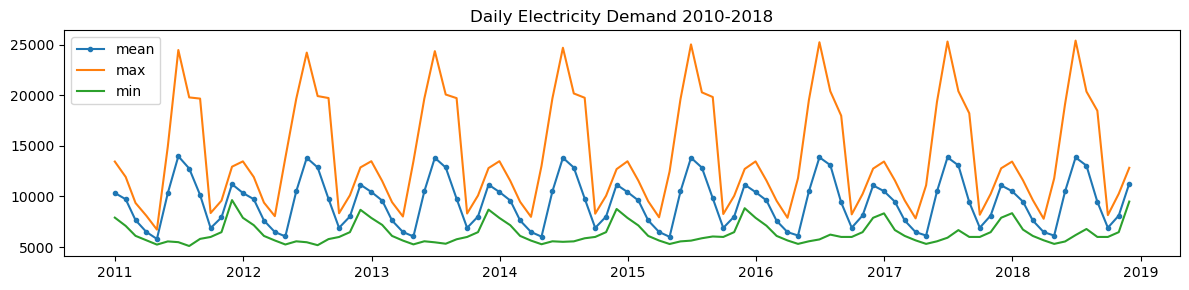

In [19]:
plot_daily(df_daily, "electricity_demand_values", "Daily Electricity Demand 2010-2018")

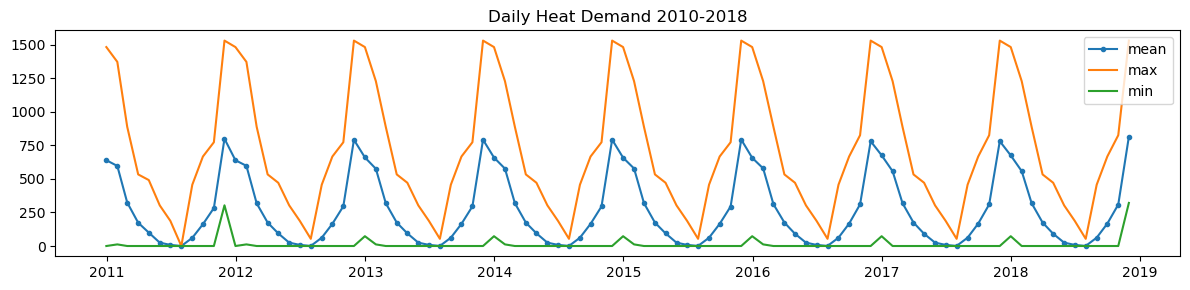

In [20]:
plot_daily(df, "heat_demand_values", "Daily Heat Demand 2010-2018")

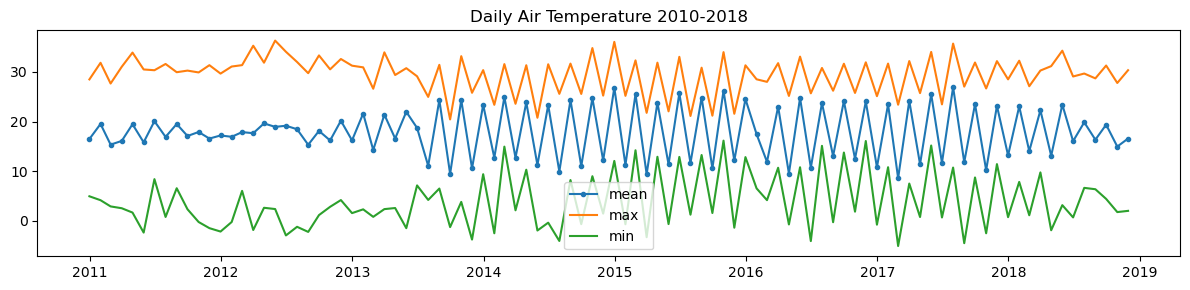

In [21]:
plot_daily(df_daily, "air_temperature", "Daily Air Temperature 2010-2018")

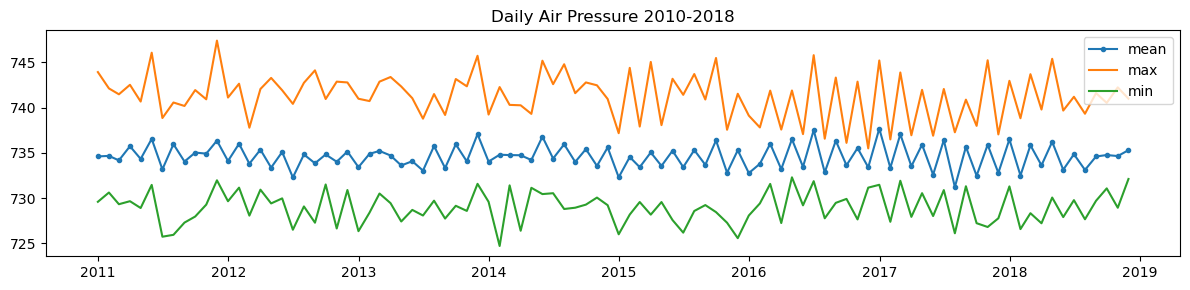

In [22]:
plot_daily(df_daily,"air_pressure", "Daily Air Pressure 2010-2018")

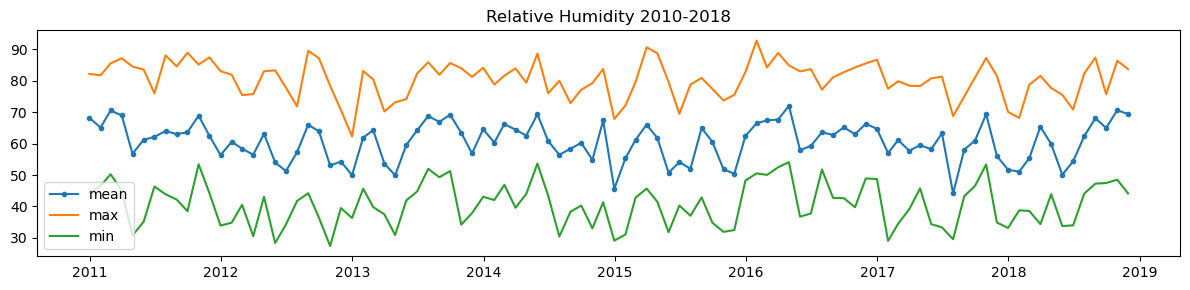

In [23]:
plot_daily(df_daily, "relative_humidity", "Relative Humidity 2010-2018")

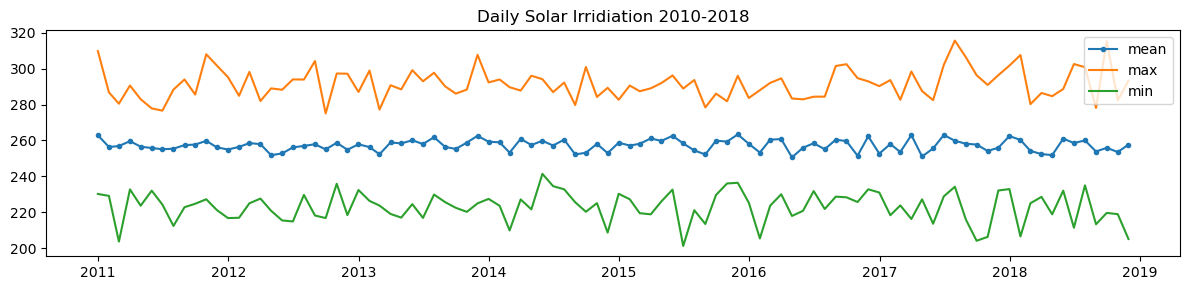

In [24]:
plot_daily(df_daily, "solar_irridiation", "Daily Solar Irridiation 2010-2018")

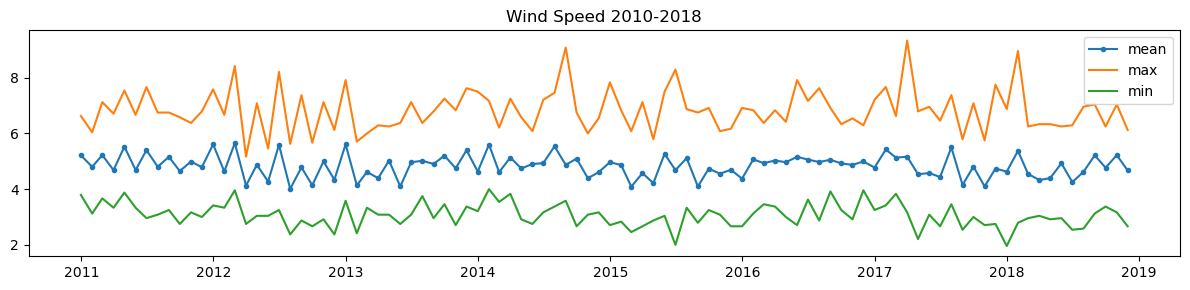

In [25]:
plot_daily(df_daily, "wind_speed", "Wind Speed 2010-2018")

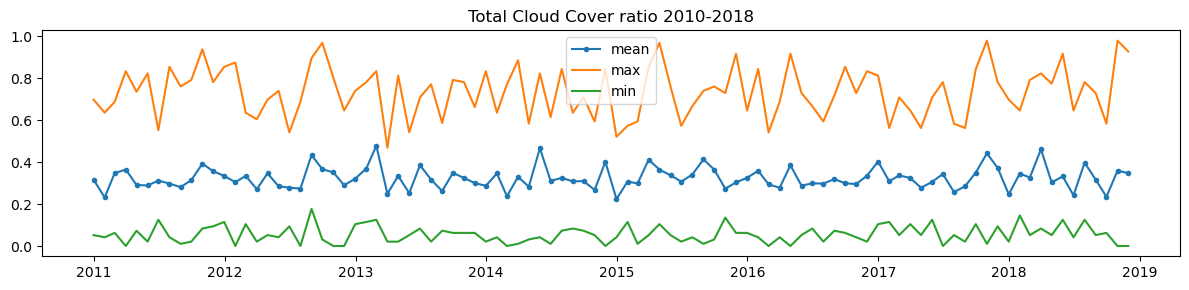

In [26]:
plot_daily(df_daily, "total_cloud_cover_percent", "Total Cloud Cover ratio 2010-2018")

## Trainning model and model evaluation

In [27]:
def train_test_set(
    df, start, end, split_time
):  # Splitting the data into training and testing sets
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test

In [28]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily,'2017-01-01','2018-11-20', "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((516, 6), (516,), (172, 6), (172,))

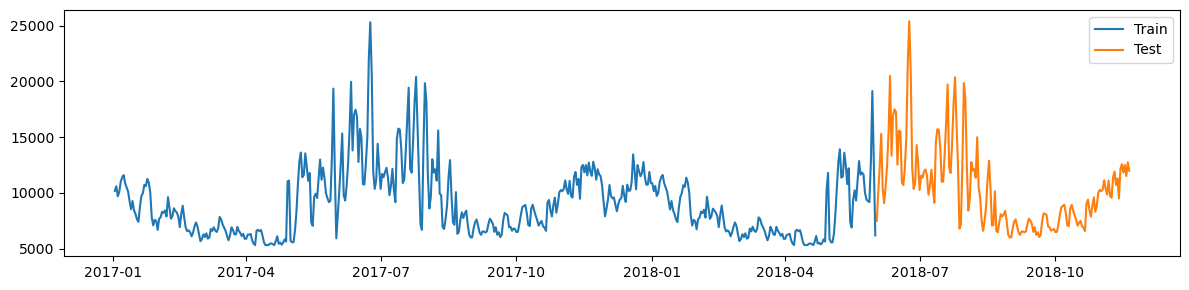

In [29]:
_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")  # Plotting the training data
ax.plot(y_test.index, y_test, label="Test")  # Plotting the testing data


plt.legend()
plt.tight_layout()

plt.show()

In [30]:
def train_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)  # Training the model
    y_pred = model.predict(X_test)  # Making predictions on the test set
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
    mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
    r2 = r2_score(y_test, y_pred)  # Calculating R2 score
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    df_results = pd.DataFrame(
        {"Time": y_test.index, "y_test": y_test, "y_pred": y_pred}
    )  # Creating a DataFrame to store results
    return df_results

In [31]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 4275.5685
MAE: 3098.8628
R2: -0.3480


<Axes: xlabel='Time'>

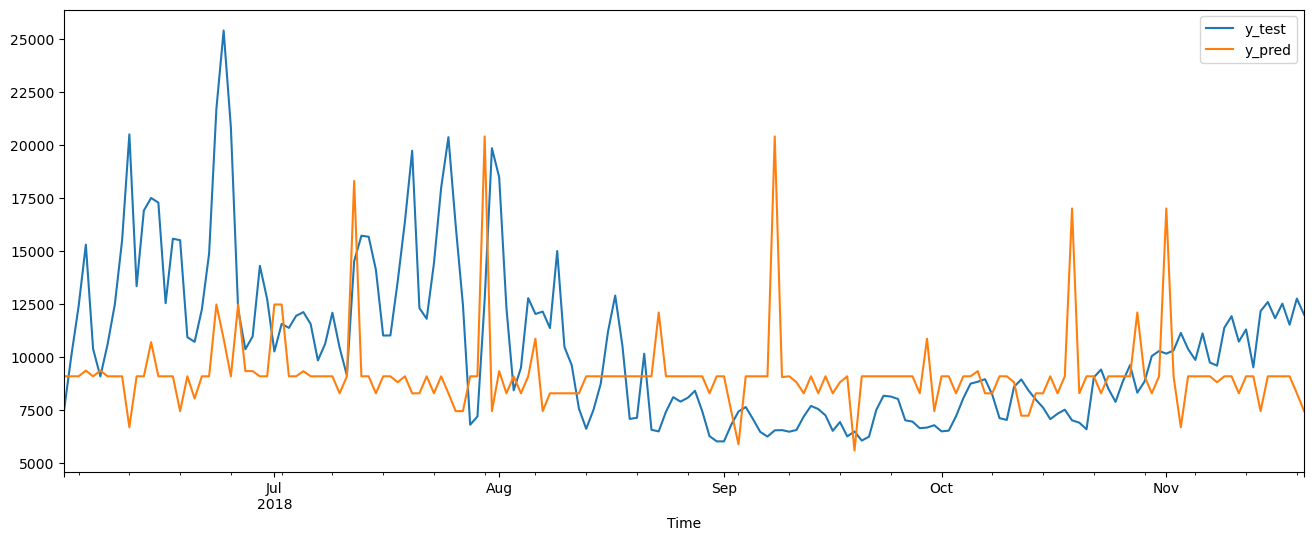

In [32]:
df_results.plot(x="Time", figsize=(16, 6))

In [33]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 4040.3194
MAE: 2880.9766
R2: -0.2038


<Axes: xlabel='Time'>

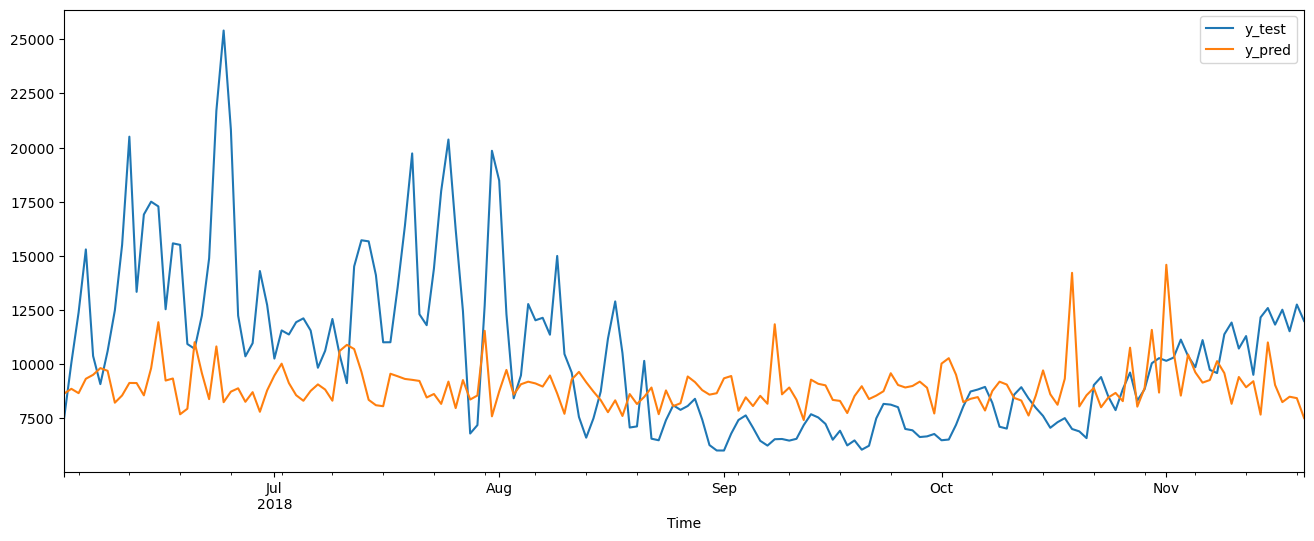

In [34]:
df_results.plot(x="Time", figsize=(16, 6))

In [35]:
from sklearn.ensemble import AdaBoostRegressor

ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 4220.1909
MAE: 2973.0639
R2: -0.3133


<Axes: xlabel='Time'>

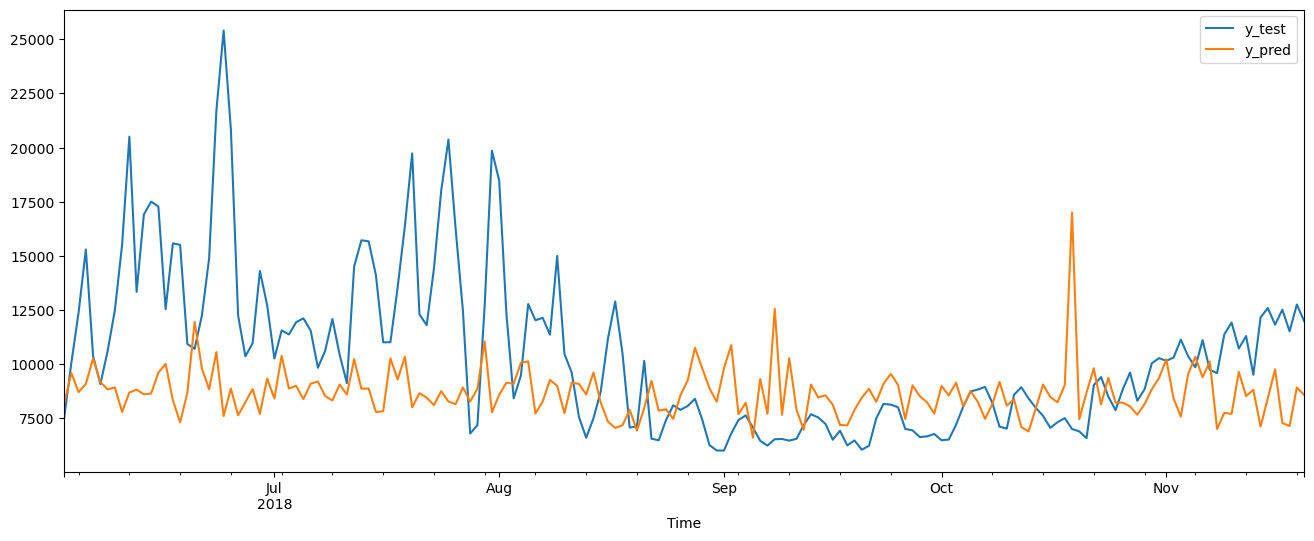

In [36]:
df_results.plot(x="Time", figsize=(16, 6))

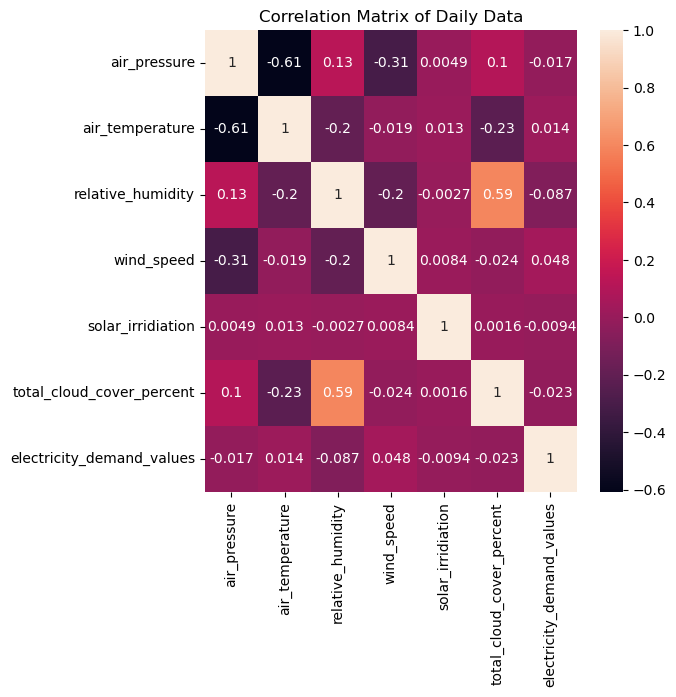

In [37]:
_, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(df_daily.corr(), annot=True, ax=ax)
ax.set_title("Correlation Matrix of Daily Data")
plt.show()


## Conclusion

- Lower performance due to the lower correlation between the features and the daily electricity demand
- More features needed to improve the performance of the model